# Exercise 1

In [1]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("single-cell-analysis-master/01-tuning-curves/code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

# Download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/z7mMiznEWOT0Iak')


## Simulate place cells

In [2]:
#parameters for 1d track
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
    
#mouse trajectory
n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 
stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)
x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

#draw spikes
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))

## A: different bin sizes

100%|█████████████████████████████████████████| 100/100 [00:30<00:00,  3.30it/s]


Text(0.5, 1.0, 'Big bin size (20cm)')

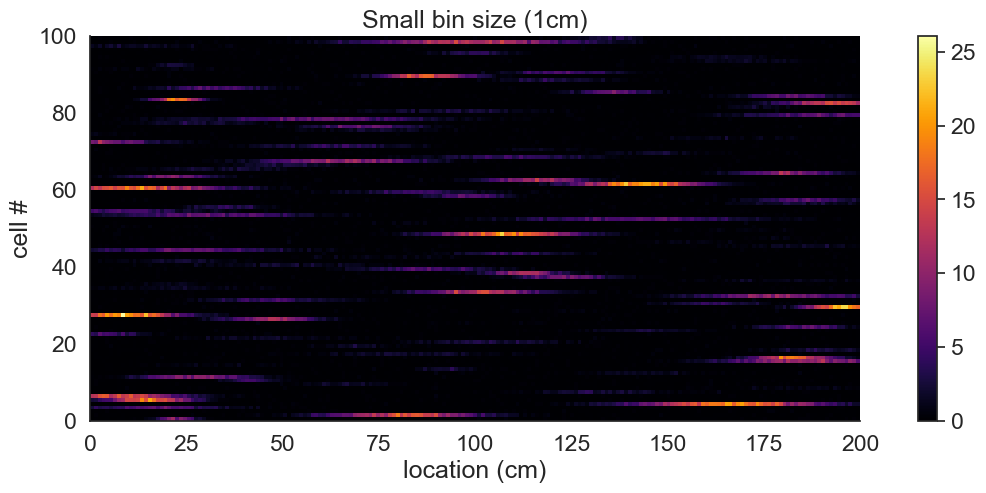

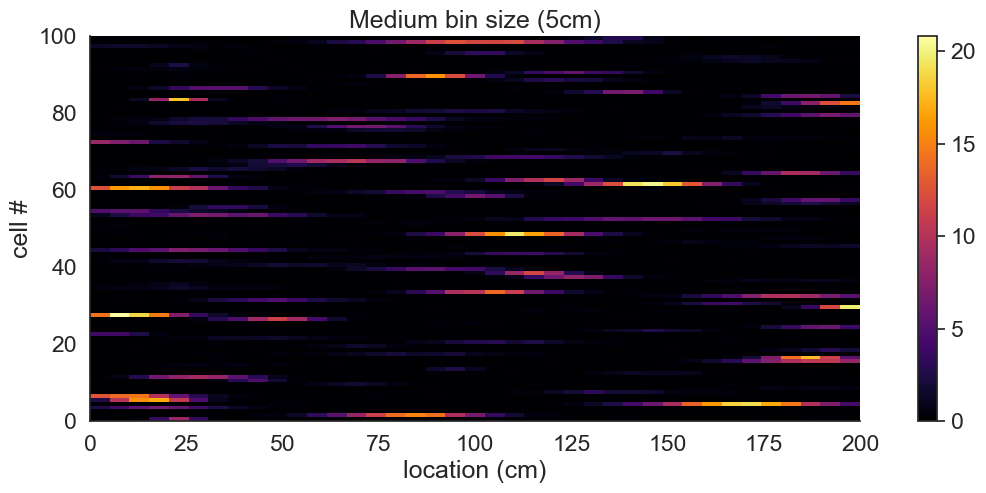

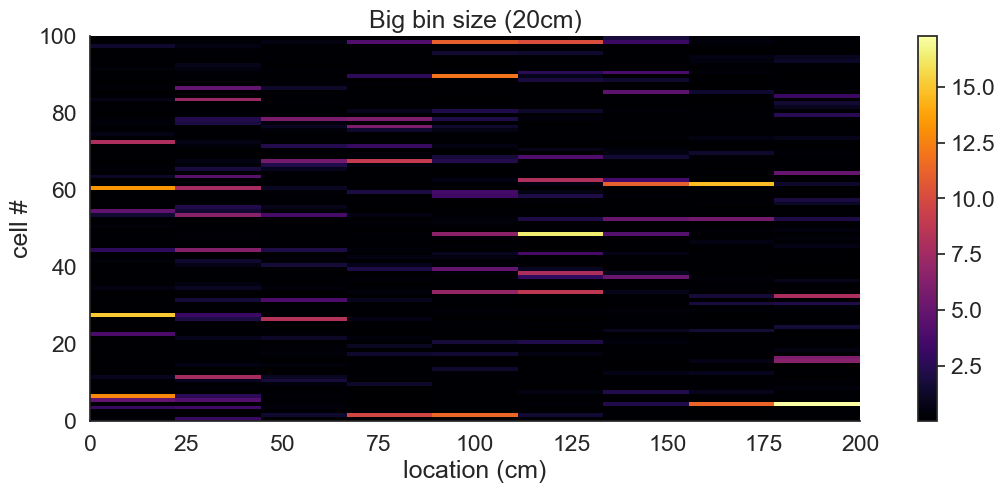

In [3]:
# the baseline noise firing rate
noise_firing_rate = 0.1 
spikes = []
for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

#positions of spikes
spike_positions = [np.interp(s, t, x) for s in spikes]

#different binnings
space_bins_small = np.arange(0., 200., 1.)
space_bins_med = np.arange(0., 200., 5.)
space_bins_big = np.arange(0., 200., 20.)
# we compute histograms for each cell
spikes_hist_s= [np.histogram(s, space_bins_small)[0] for s in spike_positions]
spikes_hist_m= [np.histogram(s, space_bins_med)[0] for s in spike_positions]
spikes_hist_l= [np.histogram(s, space_bins_big)[0] for s in spike_positions]
# put them together into a matrix of floating point numbers (for plotting)
spikes_hist_s = np.vstack(spikes_hist_s).astype(np.float64)
spikes_hist_m = np.vstack(spikes_hist_m).astype(np.float64)
spikes_hist_l = np.vstack(spikes_hist_l).astype(np.float64)
# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy_s = np.histogram(x, space_bins_small)[0] /  fps
firing_rate_maps_s = spikes_hist_s / occupancy_s 
occupancy_m = np.histogram(x, space_bins_med)[0] /  fps
firing_rate_maps_m = spikes_hist_m / occupancy_m
occupancy_l = np.histogram(x, space_bins_big)[0] /  fps
firing_rate_maps_l = spikes_hist_l / occupancy_l 

plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps_s, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title('Small bin size (1cm)')

plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps_m, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title('Medium bin size (5cm)')

plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps_l, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title('Big bin size (20cm)')


> The bigger the binsize the less pixelated the stripes look. So a big bin size will result in less accurate images of cell placement.

## B: Different baseline noise

100%|█████████████████████████████████████████| 100/100 [00:30<00:00,  3.30it/s]


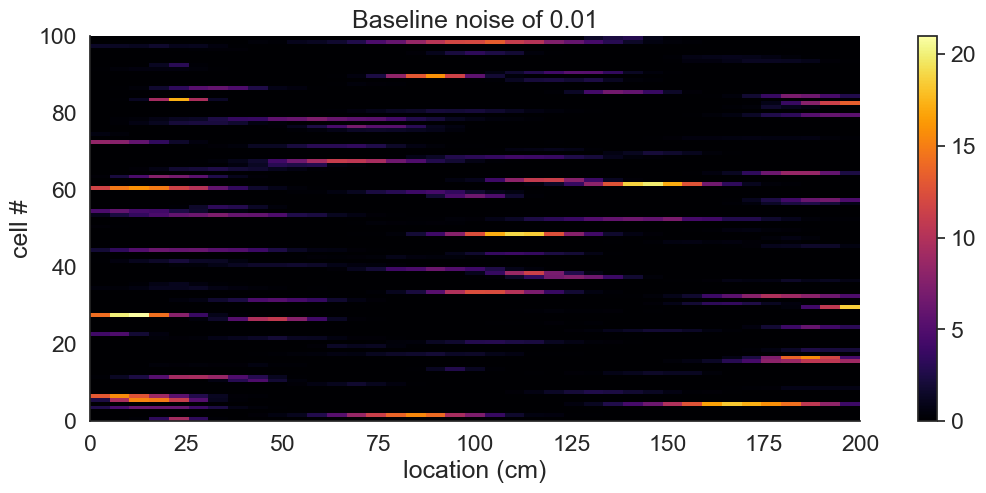

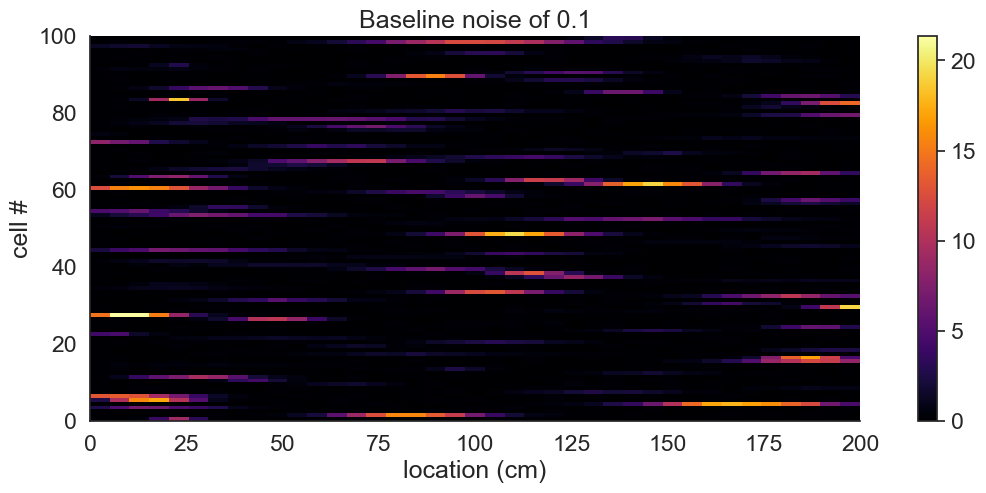

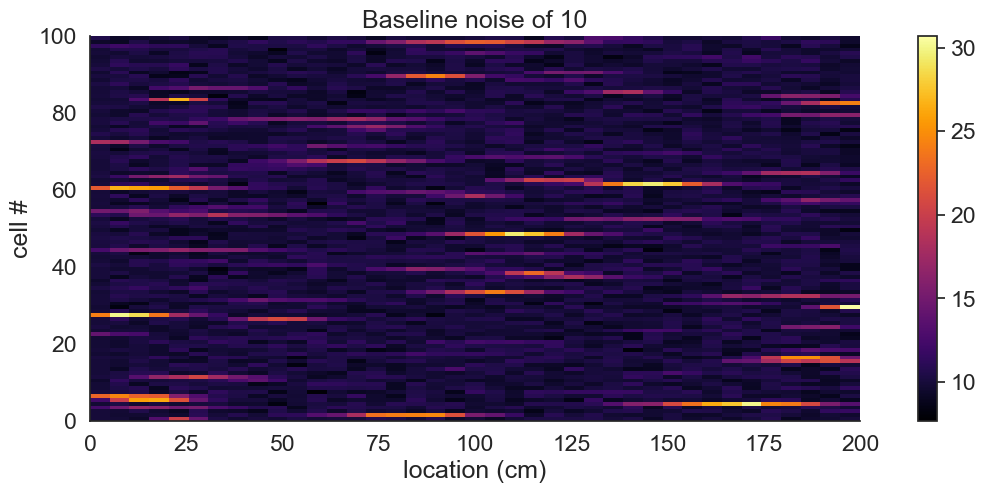

In [4]:
# the baseline noise firing rate
noise = [0.01, 0.1,10] 

for noise_firing_rate in noise:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    
    #positions of spikes
    spike_positions = [np.interp(s, t, x) for s in spikes]
    
    space_bins = np.arange(0., 200., 5.)
    # we compute histograms for each cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    firing_rate_maps = spikes_hist / occupancy 
    
    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f'Baseline noise of {noise_firing_rate}')

> How higher the baseline noise, how more the firing maps look 'purple' which means that there was more activity detected in the background. This could disrupt the image and make it less accurate on cell placement.

## C: Gaussian smoother

100%|█████████████████████████████████████████| 100/100 [00:30<00:00,  3.30it/s]


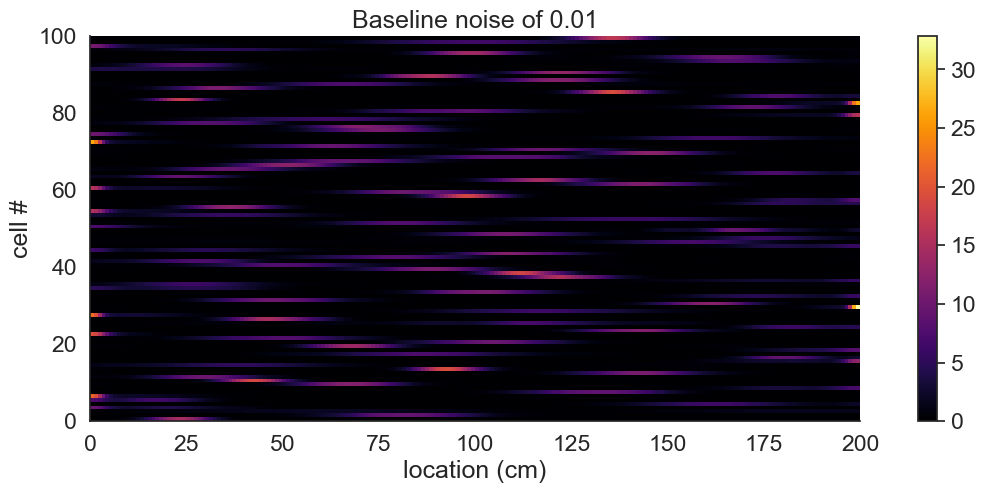

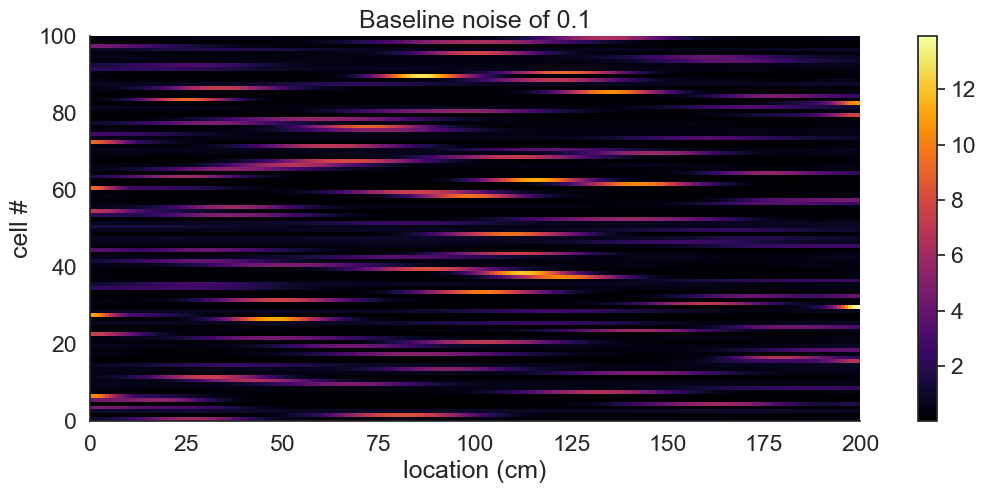

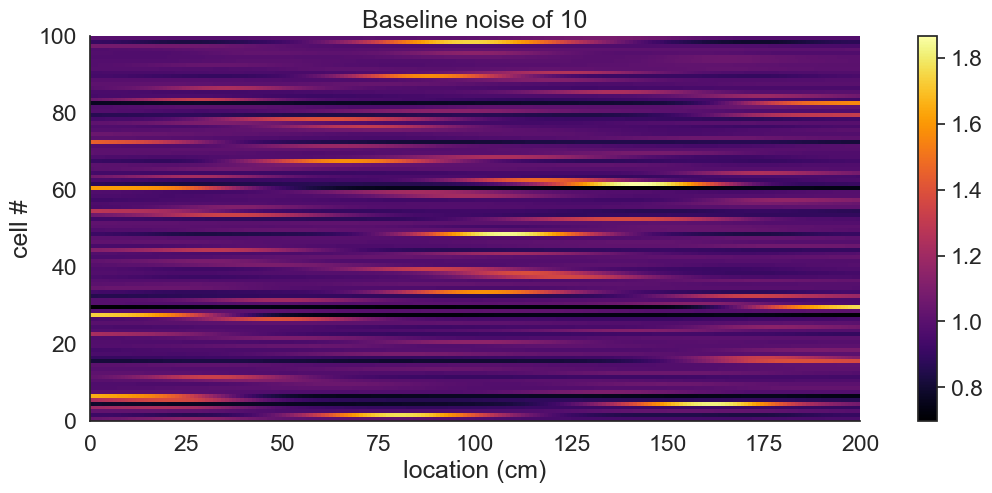

In [5]:
# the baseline noise firing rate
noise = [0.01, 0.1,10] 

for noise_firing_rate in noise:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    
    #positions of spikes
    spike_positions = [np.interp(s, t, x) for s in spikes]
    space_bins = np.arange(0., 200., 1.) #1cm bins
    
    # smooth the occupancy using guassian 
    occupancy = scipy.stats.gaussian_kde(x, bw_method=0.2)(space_bins)
    # smooth the spikes using guassian
    firing_rate_maps = []
    for s in spike_positions: 
        s = np.asarray(s).flatten() #needed to fix error in guassian_kde
        if len(s) < 2: 
            firing_rate_maps.append(np.zeros_like(space_bins))
            continue
        spike_density = scipy.stats.gaussian_kde(s, bw_method=0.2)(space_bins)
        firing_rate_maps.append(spike_density / occupancy)
    firing_rate_maps = np.vstack(firing_rate_maps)
    
    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f'Baseline noise of {noise_firing_rate}')

> It looks like the smoother actually makes the noise worse. However, the horizontal lines do look smoother compared to the 1cm bins. 

## D: Place field centers

100%|█████████████████████████████████████████| 100/100 [00:32<00:00,  3.05it/s]


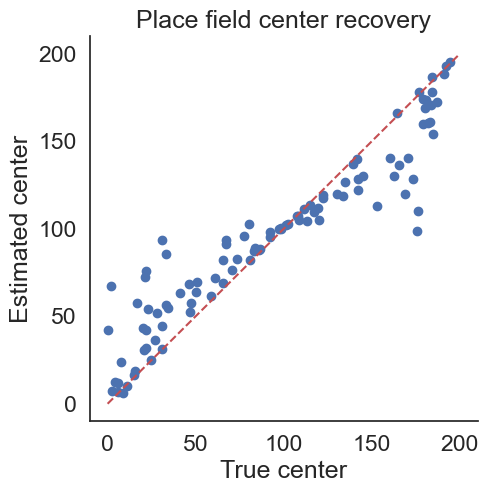

In [8]:
#compute the spike_positions
noise_firing_rate = 0.1 
spikes = []
for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)
#positions of spikes
spike_positions = [np.interp(s, t, x) for s in spikes]

#for all cells determine the center of mass
estimated_centers = []
for n in range(n_cells):
    true_center = pf_centers[n]
    N_spikes = [len(s) for s in spikes][n]
    L=0
    for i in range(len(spike_positions[n])):
        L+=spike_positions[n][i]
    center=L/N_spikes
    estimated_centers.append(center)

plt.figure(figsize=(5,5))
plt.scatter(pf_centers, estimated_centers)
plt.plot([0, 200], [0, 200], 'r--')  #y=x
plt.xlabel("True center")
plt.ylabel("Center of mass")
plt.title("Place field center")
plt.show()


> We can see that the 'center of mass' follows closely to the true center, using that calculation. This is for a noise of 0.1 and will worsen for higher noise.

# Exercise 2
## Mutual information

In [103]:
def skaggs(peak_firing_rate, place_cell_size, baseline_noise):
    #parameters for 1d track
    track_length = 200. 
    average_firing_rate = peak_firing_rate #adjust average the peak firing rate
    n_cells = 100 
    pf_centers = np.random.rand(n_cells) * track_length 
    pf_size = np.random.gamma(10,scale=place_cell_size/10, size=n_cells) #adjust the size (width) of the place fields
    pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) #the peak firing rate for each cell
    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
    #mouse trajectory
    n_runs = 20 
    av_running_speed = 10 
    fps = 30 
    running_speed_a = np.random.chisquare(10, size=n_runs) 
    running_speed_b = np.random.chisquare(10, size=n_runs) 
    stopping_time_a = np.random.chisquare(15, size=n_runs) 
    stopping_time_b = np.random.chisquare(15, size=n_runs)
    x = np.array([])
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
        run_length = len(bins) * fps / running_speed_a[i]
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
        run_length = len(bins) * fps / running_speed_b[i]
        run2 = np.linspace(len(bins)-1., 0., int(run_length))
        x = np.concatenate((x, stop1, run1, stop2, run2))
    t = np.arange(len(x))/fps
    #draw spikes
    sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    #compute the spike_positions
    noise_firing_rate = baseline_noise #adjust baseline noise
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    spike_positions = [np.interp(s, t, x) for s in spikes]
    #compute firing rate map
    space_bins = np.arange(0., 200., 5.)
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    occupancy = np.histogram(x, space_bins)[0] /  fps
    firing_rate_maps = spikes_hist / occupancy 
    #skaggs formula
    n_cells, n_bins = firing_rate_maps.shape
    epsilon=10**(-15)
    p_occ = occupancy / np.sum(occupancy)
    I_cells = np.zeros(n_cells)
    I_s=np.zeros(n_cells)
    for n in range(n_cells): #loop over neurons/place cells
        l = firing_rate_maps[n] #all bins for neuron n
        lam = np.sum(p_occ * l) #mean firing rate of neuron n
        I=0
        for x in range(n_bins): #sum over space bins
            labda = l[x]
            I+=labda*np.log2((labda+epsilon)/lam)*p_occ[x]
        I_cells[n] = I
        I_s[n]=I_cells[n]/lam
    return I_cells, I_s

100%|█████████████████████████████████████████| 100/100 [00:26<00:00,  3.75it/s]


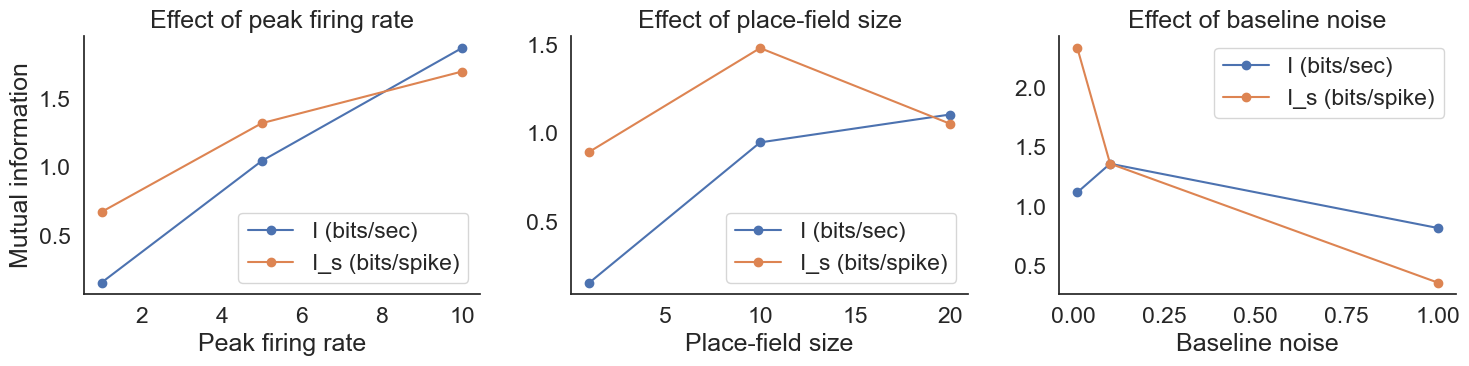

In [24]:
peak = [1,5,10]          # vary peak firing rate
size = [1,10,20]        # vary place-field size
noise = [0.01,0.1,1]   # vary baseline noise
I_peak = []
I_size = []
I_noise = []
I_s_peak = []
I_s_size = []
I_s_noise = []

# Peak firing rate
for p in peak:
    I_cells, I_s = skaggs(p, 10, 0.1) #vary peak, keep others fixed
    I_peak.append(np.mean(I_cells)) #average Saggs accros neurons
    I_s_peak.append(np.mean(I_s)) #average bits/spike across neurons
    
# Place-field size
for s in size:
        I_cells, I_s = skaggs(5, s, 0.1)
        I_size.append(np.mean(I_cells))
        I_s_size.append(np.mean(I_s))

# Baseline noise
for n in noise:
        I_cells, I_s = skaggs(5, 10, n)
        I_noise.append(np.mean(I_cells))
        I_s_noise.append(np.mean(I_s))


plt.figure(figsize=(15,4))
# Peak firing rate
plt.subplot(1,3,1)
plt.plot(peak, I_peak, '-o', label="I (bits/sec)")
plt.plot(peak, I_s_peak, '-o', label="I_s (bits/spike)")
plt.xlabel("Peak firing rate")
plt.ylabel("Mutual information")
plt.title("Effect of peak firing rate")
plt.legend()

# Place-field size
plt.subplot(1,3,2)
plt.plot(size, I_size, '-o', label="I (bits/sec)")
plt.plot(size, I_s_size, '-o', label="I_s (bits/spike)")
plt.xlabel("Place-field size")
plt.title("Effect of place-field size")
plt.legend()

# Baseline noise
plt.subplot(1,3,3)
plt.plot(noise, I_noise, '-o', label="I (bits/sec)")
plt.plot(noise, I_s_noise, '-o', label="I_s (bits/spike)")
plt.xlabel("Baseline noise")
plt.title("Effect of baseline noise")
plt.legend()

plt.tight_layout()
plt.show()


> Peak firing size: We can see that for both mutual informations an increase in parameters causes an increase in I/I_s. 
> Place field size: Mutual information peaks at the intermediate size since too small fields would not contain that many spikes but too big fields would loose it specifity.
> Baseline noise: The higher the baseline noise, the lower the mutual information. This makes sense since high noise reduces the contrast between background and neurons.
> The difference between I and I_s is slight in all plots. I tells us how much spatial information one neuron holds per second. I_s tells us how much information one spike of a neuron holds. 

# Exercise 3
## Load data

In [117]:
#import data
with open('data/linear_track_data.pickle', 'rb') as handle:
    data = pickle.load(handle)
x = data['x']
t = data['t']
spikes = data['spikes']

/var/folders/zt/1037hy2s1px83v5dgmmdyt680000gn/T/ipykernel_56778/2060514489.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


## A: Position, time and spike

In [118]:
from ipywidgets import interact
import ipywidgets as widgets

def plot_unit(i): #plot per neuron
    plt.figure(figsize=(10,5))
    plt.plot(t, x) #plot the position of the animal against time
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.') #plot the positions and times of the spikes
    plt.xlabel('Time (s)')
    plt.ylabel('Position on track (cm)')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(len(spikes)-1), value=0))

interactive(children=(IntSlider(value=0, description='i', max=71), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_unit(i)>

> In blue is the path of the animal and the red dots are the spikes. We see that some cells have spikes all allong the blue line while others have less spikes and more located around the turing points.

## B: Firing rate maps

(95,)


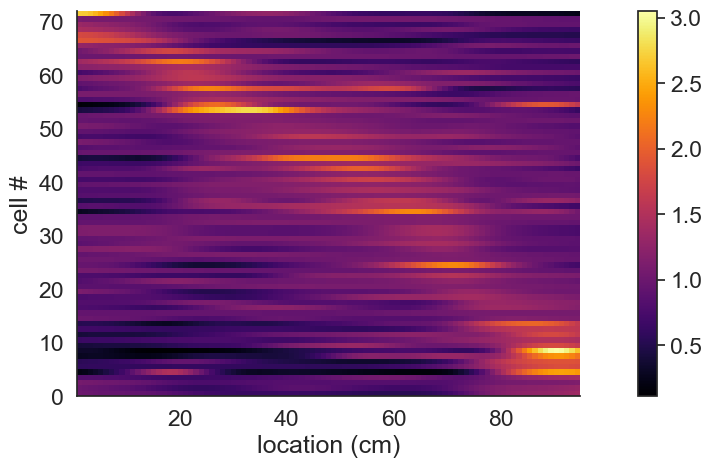

In [108]:
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(x.min(), x.max(), 1.)

# smooth the spikes using guassian, I did this to make the real data look better
occupancy = scipy.stats.gaussian_kde(x, bw_method=0.2)(space_bins)
firing_rate_maps = []
for s in spike_positions: 
    s = np.asarray(s).flatten() 
    if len(s) < 2: 
        firing_rate_maps.append(np.zeros_like(space_bins))
        continue
    spike_density = scipy.stats.gaussian_kde(s, bw_method=0.2)(space_bins)
    firing_rate_maps.append(spike_density / occupancy)
firing_rate_maps = np.vstack(firing_rate_maps)

#plot firing rate maps of all neurons
plt.figure(figsize=(15,5))
peak_locations = firing_rate_maps.argmax(axis=1) 
ix = np.argsort(peak_locations) #sort by peak locations
plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [space_bins[0], space_bins[-1], 0, len(spikes)])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

## C: Spatial information

In [110]:
def spatial_information(neuron):    
    #skaggs formula
    n_cells, n_bins=firing_rate_maps.shape
    epsilon=10**(-15)
    p_occ = occupancy / np.sum(occupancy)
    l = firing_rate_maps[neuron] #all bins for neuron 
    lam = np.sum(p_occ * l) #mean firing rate of neuron 
    I=0
    for i in range(n_bins): #sum over space bins
        labda = l[i]
        I+=labda*np.log2((labda+epsilon)/lam)*p_occ[i]
    I_s=I/lam
    return I, I_s

(np.float64(0.009032451036280767), np.float64(0.008758541913334786))


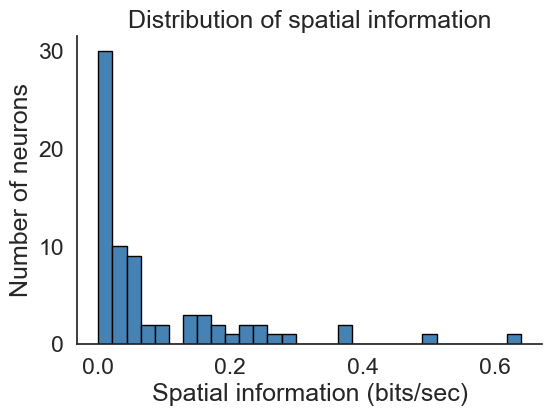

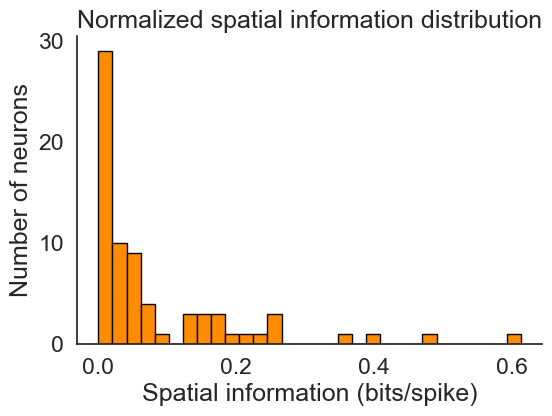

In [113]:
# compute spatial information for each neuron
I_cells = []
I_s_cells = []

for n in range(firing_rate_maps.shape[0]):
    I, I_s = spatial_information(n)
    I_cells.append(I)
    I_s_cells.append(I_s)

I_cells = np.array(I_cells)
I_s_cells = np.array(I_s_cells)

#I
plt.figure(figsize=(6,4))
plt.hist(I_cells, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Spatial information (bits/sec)')
plt.ylabel('Number of neurons')
plt.title('Distribution of spatial information')
plt.show()

#I_s
plt.figure(figsize=(6,4))
plt.hist(I_specific, bins=30, color='darkorange', edgecolor='black')
plt.xlabel('Spatial information (bits/spike)')
plt.ylabel('Number of neurons')
plt.title('Normalized spatial information distribution')
plt.show()

> We see that most neurons have little spatial information and only a few have high spatial information. This makes sense because not all neuron have the same functions.

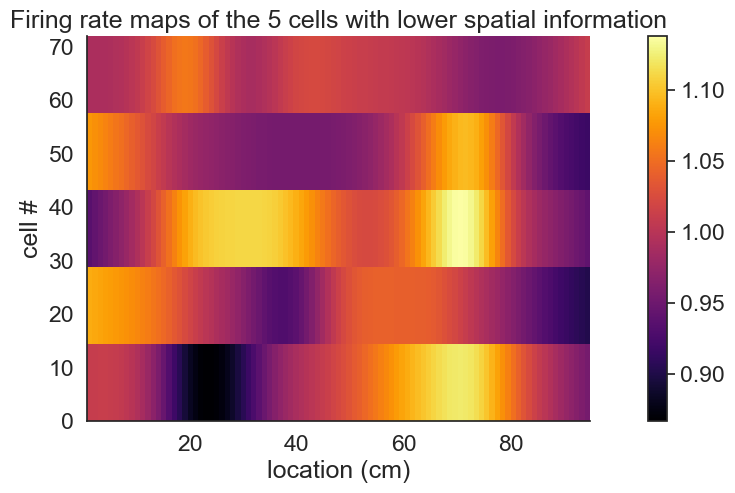

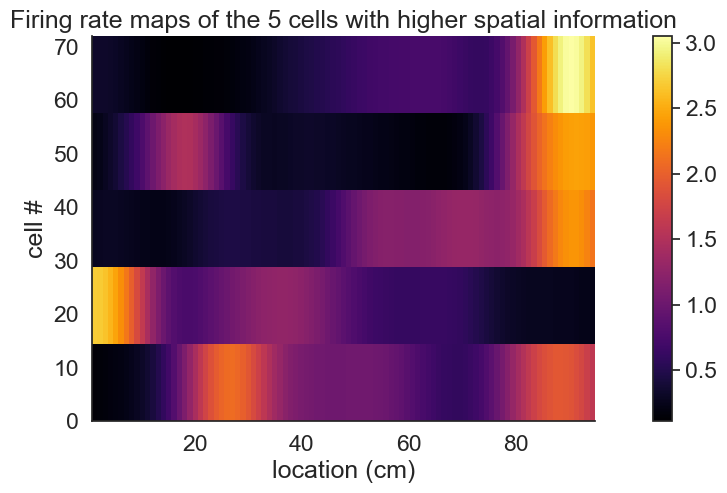

In [119]:
# sort indices
low_ix = np.argsort(I_cells)[:5] #lowest five
high_ix = np.argsort(I_cells)[-5:][::-1]  # highest five

#plot lowest 5
plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps[low_ix, :], cmap='inferno', extent = [space_bins[0], space_bins[-1], 0, len(spikes)])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.title('Firing rate maps of the 5 cells with lower spatial information')
plt.colorbar()

#plot highest 5
plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps[high_ix, :], cmap='inferno', extent = [space_bins[0], space_bins[-1], 0, len(spikes)])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.title('Firing rate maps of the 5 cells with higher spatial information')
plt.colorbar()

> The lowest 5 neurons have a highest activity score of about 1.1 while the highers 5 neurons are at most 3.0. We also see that the lowest neurons stay more on their baseline and probably are more effected by the background noise. While the highest neurons have clear spikes and clear areas of rest. 